# Machine Learning Assignment  -2
# Student ID :  2025AA05921
# Name : Kamaraj

# Loan Approval Classification - Model - 1 - Logistic Regression

In [1]:
# Import the required libraries 
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns 
from sklearn.model_selection import train_test_split, cross_val_score  
from sklearn.preprocessing import LabelEncoder, StandardScaler  
from sklearn.linear_model import LogisticRegression  
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, matthews_corrcoef, precision_score, recall_score, f1_score, confusion_matrix, roc_curve  
import os
from sklearn.metrics import confusion_matrix
import joblib
import warnings 
warnings.filterwarnings('ignore')  

# Set visualization style - seaborn
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print(f"Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Step 1: Data Loading
# Read the dataset
df_raw = pd.read_csv('../data/loan_data.csv')

print(f"Dataset loaded successfully!")
print(f"Shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
print("\nFirst 5 rows:")
print(df_raw.head())

Dataset loaded successfully!
Shape: (45000, 14)
Columns: ['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'loan_status']

First 5 rows:
   person_age person_gender person_education  person_income  person_emp_exp  \
0        22.0        female           Master        71948.0               0   
1        21.0        female      High School        12282.0               0   
2        25.0        female      High School        12438.0               3   
3        23.0        female         Bachelor        79753.0               0   
4        24.0          male           Master        66135.0               1   

  person_home_ownership  loan_amnt loan_intent  loan_int_rate  \
0                  RENT    35000.0    PERSONAL          16.02   
1                   OWN     1000.0   EDUCATION  

In [3]:
# Step 2:  EDA 
print("Dataset Information:")
print(df_raw.info())

print("\nTarget Variable Distribution:")
print(df_raw['loan_status'].value_counts())
print(f"Class Balance: {df_raw['loan_status'].value_counts(normalize=True).round(4)}") # Class  Distribution

print("\nMissing Values:")
print(df_raw.isnull().sum()) # Ensures that we have no missing values in the dataset

print("\nBasic Statistics:")
print(df_raw.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_lo

In [4]:
# Step 3: Train-Test Split  for the RAW data before any preprocessing to provide in the streamlit app

# Separate the features (X) and target (y) from RAW data
X_raw = df_raw.drop('loan_status', axis=1)  # Features set 
y_raw = df_raw['loan_status'] # Target variable

#  stratified train-test split
# - test_size=0.25 - 25% for testing, 75% for training
# - random_state=42
# - stratify=y_raw - Class distribution based on the loan status
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw,
    test_size=0.25, # Test Size 
    random_state=42,
    stratify=y_raw
)

data_dir = '../data' # To Store the train and test datasets for the streamlit app

# Combine features and target for training data - For Training 
train_data_raw = X_train_raw.copy()
train_data_raw['loan_status'] = y_train_raw.values

# Combine features and target for test data  - For Testing 
test_data_raw = X_test_raw.copy()
test_data_raw['loan_status'] = y_test_raw.values

# Save to CSV files for all other data models 
train_file_path = os.path.join(data_dir, 'train_data.csv') # save the training data to a CSV file
test_file_path = os.path.join(data_dir, 'test_data.csv') # save the test data to a CSV file

train_data_raw.to_csv(train_file_path, index=False) # Index not required in the CSV file
test_data_raw.to_csv(test_file_path, index=False)


print(f"Training and testing datasets Created!")
print(f"Training data shape: {train_data_raw.shape}")
print(f"Testing data shape: {test_data_raw.shape}")

Training and testing datasets Created!
Training data shape: (33750, 14)
Testing data shape: (11250, 14)


In [5]:
# Step 4: Load Training and Test Data for Model 1

# Load training data first 
train_data = pd.read_csv('../data/train_data.csv')
print(f"Training data Shape: {train_data.shape}")

# Load test data
test_data = pd.read_csv('../data/test_data.csv')
print(f"Test data Shape: {test_data.shape}")


Training data Shape: (33750, 14)
Test data Shape: (11250, 14)


In [6]:
# Step 5: Data Preprocessing - Categorical Encoding for Logistic Regression

# Work on copy
df_train = train_data.copy()
df_test = test_data.copy()

# This are all the categorical columns in the dataset that need to be encoded 
categorical_cols = [
    'person_gender',
    'person_education',
    'person_home_ownership',
    'loan_intent',
    'previous_loan_defaults_on_file'
]

# Store label encoder for the test data
label_encoders = {}

for col in categorical_cols:
    if col in df_train.columns:
        print(f"\nEncoding '{col}':")
        print(f"  Training unique values: {df_train[col].unique()}")
        
        # Create and fit encoder on TRAINING data only
        le = LabelEncoder() # Create Label Encoder
        df_train[col] = le.fit_transform(df_train[col].astype(str))
        
        # Apply same encoding to TEST data
        df_test[col] = le.transform(df_test[col].astype(str))
        
        # Store encoder
        label_encoders[col] = le
        
        print(f"Encoded values: {sorted(df_train[col].unique())}")

print("Categorical encoding done for both train and test datasets.")


Encoding 'person_gender':
  Training unique values: ['female' 'male']
Encoded values: [np.int64(0), np.int64(1)]

Encoding 'person_education':
  Training unique values: ['Associate' 'Bachelor' 'High School' 'Master' 'Doctorate']
Encoded values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Encoding 'person_home_ownership':
  Training unique values: ['MORTGAGE' 'RENT' 'OWN' 'OTHER']
Encoded values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Encoding 'loan_intent':
  Training unique values: ['EDUCATION' 'DEBTCONSOLIDATION' 'MEDICAL' 'HOMEIMPROVEMENT' 'VENTURE'
 'PERSONAL']
Encoded values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Encoding 'previous_loan_defaults_on_file':
  Training unique values: ['No' 'Yes']
Encoded values: [np.int64(0), np.int64(1)]
Categorical encoding done for both train and test datasets.


In [7]:
# Step 6: Separate Features and Target
# Training data
X_train = df_train.drop('loan_status', axis=1) # Drop the target column to get features
y_train = df_train['loan_status'] # Target variable

# Test data
X_test = df_test.drop('loan_status', axis=1) # Drop the target column to get features
y_test = df_test['loan_status'] # Target variable

print(f"Training features (X_train): {X_train.shape}")
print(f"Training target (y_train): {y_train.shape}")
print(f"Test features (X_test): {X_test.shape}")
print(f"Test target (y_test): {y_test.shape}")

print(f"\nFeature columns: {list(X_train.columns)}") # Feature columns in the training data
print(f"Target classes: {sorted(y_train.unique())}") # Target classes in the training data

print("Features and target separated successfully")

Training features (X_train): (33750, 13)
Training target (y_train): (33750,)
Test features (X_test): (11250, 13)
Test target (y_test): (11250,)

Feature columns: ['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file']
Target classes: [np.int64(0), np.int64(1)]
Features and target separated successfully


In [8]:
# Step 7: Feature Scaling 

scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data 
X_test_scaled = scaler.transform(X_test)

print(f"\nScaled training data shape: {X_train_scaled.shape}")
print(f"Scaled test data shape: {X_test_scaled.shape}")

print("Feature scaling completed!")


Scaled training data shape: (33750, 13)
Scaled test data shape: (11250, 13)
Feature scaling completed!


In [9]:
# Step 8: Model Training - Logistic Regression

model = LogisticRegression(
    max_iter=50,    # Maximum iterations for convergence
    random_state=42  
)

print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Features: {X_train_scaled.shape[1]}")

# Train the model
model.fit(X_train_scaled, y_train)

print(f"Model training completed!")
print(f"Model converged in {model.n_iter_[0]} iterations")

Training samples: 33750
Features: 13
Model training completed!
Model converged in 24 iterations


In [10]:
# Step 9: Model Predictions on TEST Data

# Make predictions
y_pred = model.predict(X_test_scaled)  # Predicted classes (0/1)
y_prob = model.predict_proba(X_test_scaled)[:, 1]  # Probability of class 1

print(f"Test samples: {len(y_test)}")
print(f"Predictions generated: {len(y_pred)}")

#  prediction distribution
unique, counts = np.unique(y_pred, return_counts=True)
print(f"\nPrediction Distribution:")
for val, count in zip(unique, counts):
    print(f"  Class {val}: {count} predictions ({count/len(y_pred)*100:.1f}%)")

Test samples: 11250
Predictions generated: 11250

Prediction Distribution:
  Class 0: 8863 predictions (78.8%)
  Class 1: 2387 predictions (21.2%)


In [11]:
# Step 10: Model Evaluation - Core Metrics

print("MODEL EVALUATION ON TEST DATA")

# 1. Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"1. Accuracy: {accuracy:.4f}")

# 2. AUC Score
auc = roc_auc_score(y_test, y_prob)
print(f"2. AUC Score: {auc:.4f}")

# 3. Precision
precision = precision_score(y_test, y_pred, average='weighted')
print(f"3. Precision: {precision:.4f}")

# 4. Recall
recall = recall_score(y_test, y_pred, average='weighted')
print(f"4. Recall: {recall:.4f}")

# 5. F1 Score
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"5. F1 Score: {f1:.4f}")

# 6. Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred)
print(f"6. MCC Score: {mcc:.4f}")


MODEL EVALUATION ON TEST DATA
1. Accuracy: 0.8968
2. AUC Score: 0.9515
3. Precision: 0.8953
4. Recall: 0.8968
5. F1 Score: 0.8959
6. MCC Score: 0.6969


In [12]:
# Step 11: Classification Report and confusion matrix 

print("CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred, target_names=['Rejected (0)', 'Approved (1)']))

cm = confusion_matrix(y_test, y_pred)

print("\nCONFUSION MATRIX")
print("-" * 30)
print("Actual\\Predicted    0     1")
print(f"0 (Rejected)     {cm[0,0]:4d}  {cm[0,1]:4d}")
print(f"1 (Approved)     {cm[1,0]:4d}  {cm[1,1]:4d}")

# Calculate True/False Positives/Negatives
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Component values:")
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")  
print(f"True Positives (TP):  {tp}")



CLASSIFICATION REPORT
              precision    recall  f1-score   support

Rejected (0)       0.93      0.94      0.93      8750
Approved (1)       0.78      0.75      0.76      2500

    accuracy                           0.90     11250
   macro avg       0.85      0.84      0.85     11250
weighted avg       0.90      0.90      0.90     11250


CONFUSION MATRIX
------------------------------
Actual\Predicted    0     1
0 (Rejected)     8226   524
1 (Approved)      637  1863

Confusion Matrix Component values:
True Negatives (TN):  8226
False Positives (FP): 524
False Negatives (FN): 637
True Positives (TP):  1863


CREATING MODEL VISUALIZATIONS


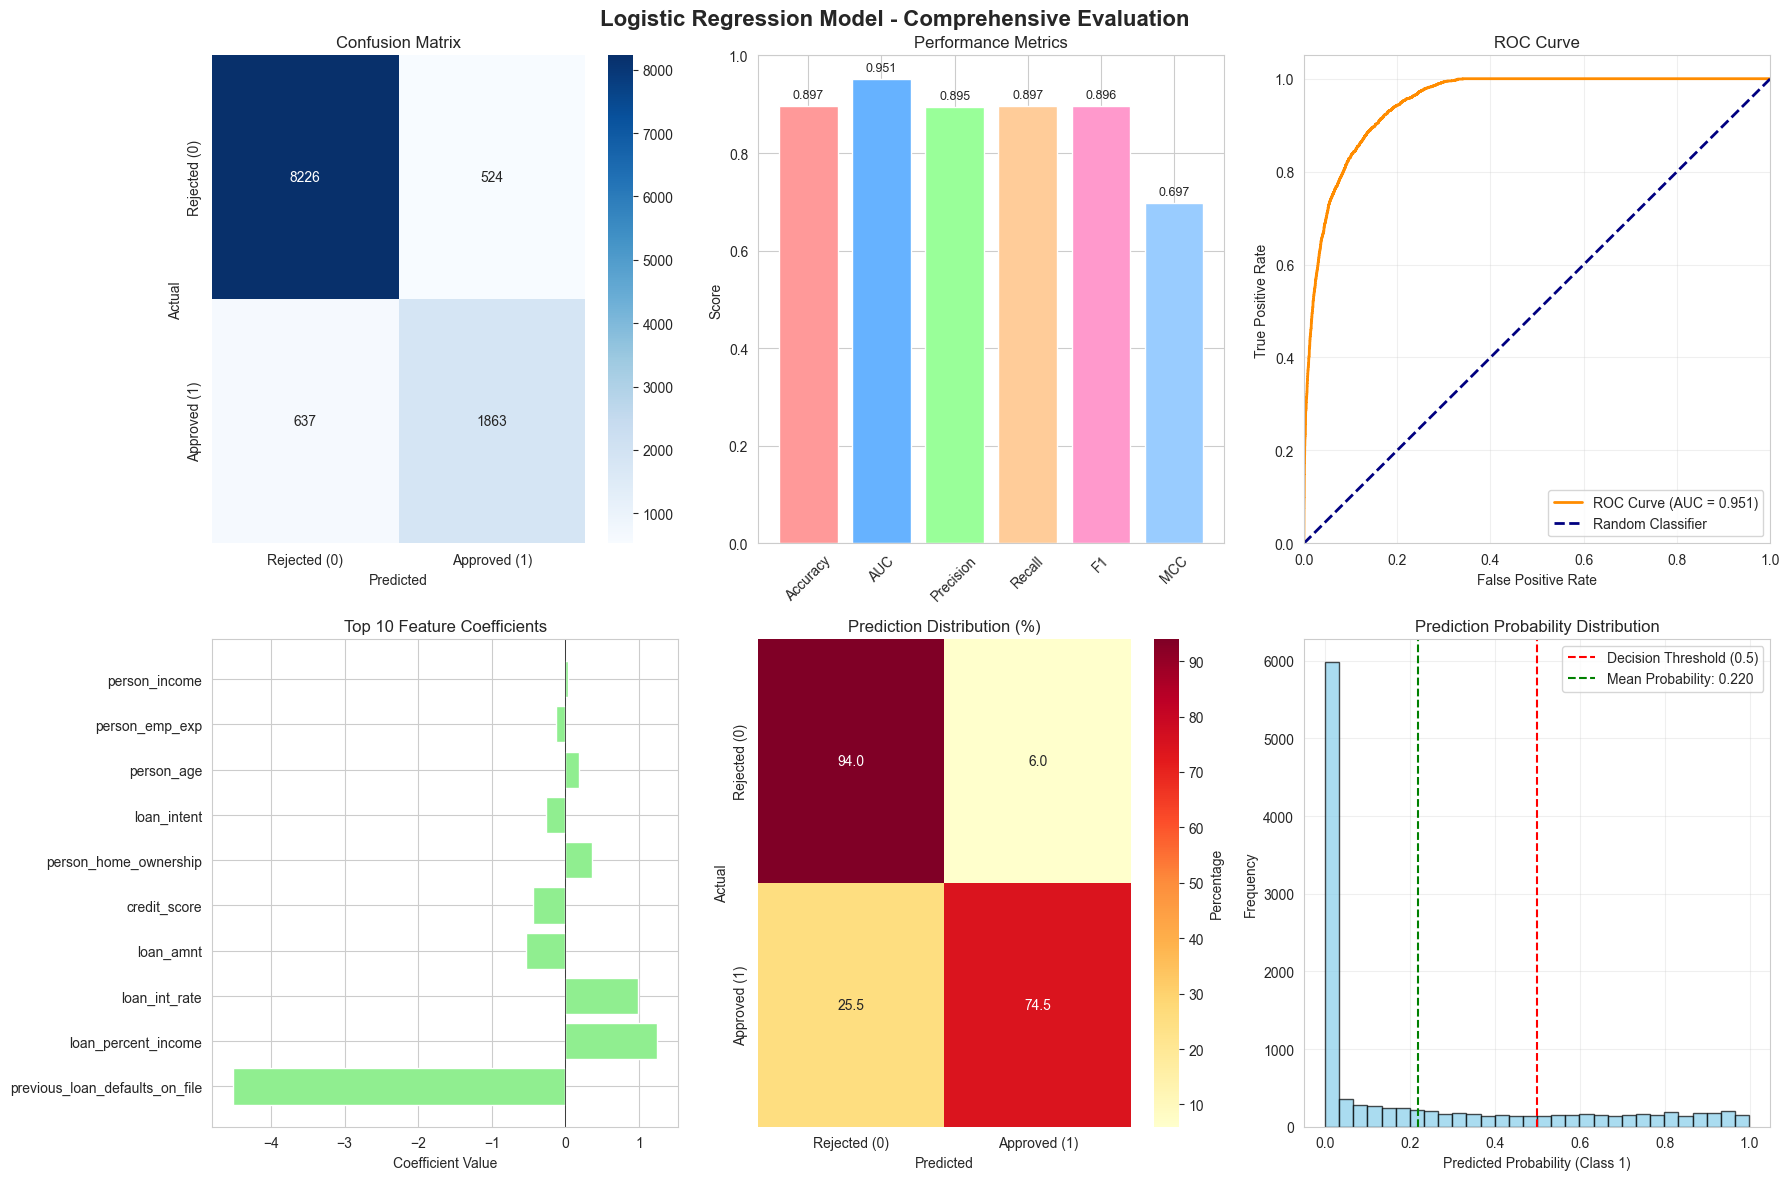

In [13]:
# Step 12: Model  Visualizations

print("CREATING MODEL VISUALIZATIONS")

# Created a  figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Logistic Regression Model - Comprehensive Evaluation', fontsize=16, fontweight='bold')

# 1. Confusion Matrix 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Rejected (0)', 'Approved (1)'], 
            yticklabels=['Rejected (0)', 'Approved (1)'], ax=axes[0,0])
axes[0,0].set_title('Confusion Matrix')
axes[0,0].set_ylabel('Actual')
axes[0,0].set_xlabel('Predicted')

# 2. Metrics Comparison
metrics_names = ['Accuracy', 'AUC', 'Precision', 'Recall', 'F1', 'MCC']
metrics_values = [accuracy, auc, precision, recall, f1, mcc]
bars = axes[0,1].bar(metrics_names, metrics_values, color=['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC', '#99CCFF'])
axes[0,1].set_title('Performance Metrics')
axes[0,1].set_ylabel('Score')
axes[0,1].set_ylim(0, 1)
axes[0,1].tick_params(axis='x', rotation=45)
for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[0,1].text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{metrics_values[i]:.3f}', 
                   ha='center', va='bottom', fontsize=9)

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0,2].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc:.3f})')
axes[0,2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[0,2].set_xlim([0.0, 1.0])
axes[0,2].set_ylim([0.0, 1.05])
axes[0,2].set_xlabel('False Positive Rate')
axes[0,2].set_ylabel('True Positive Rate')
axes[0,2].set_title('ROC Curve')
axes[0,2].legend(loc="lower right")
axes[0,2].grid(True, alpha=0.3)

# 4. Feature Coefficients 
feature_coefs = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_[0]
})
feature_coefs['abs_coefficient'] = abs(feature_coefs['coefficient'])
feature_coefs = feature_coefs.sort_values('abs_coefficient', ascending=False).head(10)

axes[1,0].barh(range(len(feature_coefs)), feature_coefs['coefficient'], color='lightgreen')
axes[1,0].set_yticks(range(len(feature_coefs)))
axes[1,0].set_yticklabels(feature_coefs['feature'])
axes[1,0].set_title('Top 10 Feature Coefficients')
axes[1,0].set_xlabel('Coefficient Value')
axes[1,0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# 5. Prediction Distribution
pred_df = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
pred_crosstab = pd.crosstab(pred_df['Actual'], pred_df['Predicted'], normalize='index') * 100
sns.heatmap(pred_crosstab, annot=True, fmt='.1f', cmap='YlOrRd', 
            xticklabels=['Rejected (0)', 'Approved (1)'], 
            yticklabels=['Rejected (0)', 'Approved (1)'], ax=axes[1,1], cbar_kws={'label': 'Percentage'})
axes[1,1].set_title('Prediction Distribution (%)')
axes[1,1].set_ylabel('Actual')
axes[1,1].set_xlabel('Predicted')

# 6. Prediction Probability Distribution
axes[1,2].hist(y_prob, bins=30, color='skyblue', alpha=0.7, edgecolor='black')
axes[1,2].axvline(0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')
axes[1,2].axvline(np.mean(y_prob), color='green', linestyle='--', label=f'Mean Probability: {np.mean(y_prob):.3f}')
axes[1,2].set_title('Prediction Probability Distribution')
axes[1,2].set_xlabel('Predicted Probability (Class 1)')
axes[1,2].set_ylabel('Frequency')
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [14]:
# Step 13: Results 
results_summary = {
    'Model Name': '1. Logistic Regression',
    'Accuracy': f'{accuracy:.4f}',
    'AUC': f'{auc:.4f}',
    'Precision': f'{precision:.4f}',
    'Recall': f'{recall:.4f}',
    'F1': f'{f1:.4f}',
    'MCC': f'{mcc:.4f}'
}

for metric, value in results_summary.items():
    print(f"{metric:15}: {value}")


Model Name     : 1. Logistic Regression
Accuracy       : 0.8968
AUC            : 0.9515
Precision      : 0.8953
Recall         : 0.8968
F1             : 0.8959
MCC            : 0.6969


In [15]:
# Step 14: Save Trained Model to JOBLIB File

model_dir = '../model' # To Store the trained model,scalar,encoders for test data

# Save the trained Logistic Regression model
model_path = os.path.join(model_dir, '1_logistic_regression_model.joblib')
joblib.dump(model, model_path)
print(f"Model saved to: {model_path}")

# save the scaler 
scaler_path = os.path.join(model_dir, '1_logistic_regression_scaler.joblib')
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to: {scaler_path}")

# Save label encoders 
encoders_path = os.path.join(model_dir, '1_logistic_regression_encoders.joblib')
joblib.dump(label_encoders, encoders_path)
print(f"Label encoders saved to: {encoders_path}")



Model saved to: ../model\1_logistic_regression_model.joblib
Scaler saved to: ../model\1_logistic_regression_scaler.joblib
Label encoders saved to: ../model\1_logistic_regression_encoders.joblib
